In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# data extraction and exploration


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df_train = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "crawford/emnist",
    "emnist-letters-train.csv"
)

df_test = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "crawford/emnist",
    "emnist-letters-test.csv"
)

/tmp/ipython-input-2983435586.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_train = kagglehub.load_dataset(


Using Colab cache for faster access to the 'emnist' dataset.


/tmp/ipython-input-2983435586.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_test = kagglehub.load_dataset(


Using Colab cache for faster access to the 'emnist' dataset.


In [ ]:
df_train.shape, df_test.shape

((88799, 785), (14799, 785))

In [ ]:
df_train.head()

,23,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.406,0.407,0.408,0.409,0.410,0.411,0.412,0.413,0.414,0.415
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,17,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_test.head()


,1,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.548,0.549,0.550,0.551,0.552,0.553,0.554,0.555,0.556,0.557
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_train.rename(columns={'23': 'label'}, inplace=True)
df_test.rename(columns={'1': 'label'}, inplace=True)


In [ ]:
df_train.head()

,label,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.406,0.407,0.408,0.409,0.410,0.411,0.412,0.413,0.414,0.415
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,17,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_test.head()

,label,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.548,0.549,0.550,0.551,0.552,0.553,0.554,0.555,0.556,0.557
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0




# data preproccessing

In [ ]:
X_train = df_train.drop("label", axis=1).values
y_train = df_train["label"].values

X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

print("Training Random Forest on HOG + PCA features with cross-validation...")

rf_model_hog_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

rf_scores_hog_pca = cross_val_score(rf_model_hog_pca, X_train_hog_pca, y_train, cv=kfold, scoring='accuracy')

print("Random Forest with HOG + PCA CV Accuracy per Fold:", rf_scores_hog_pca)
print("Random Forest Average CV Accuracy with HOG + PCA:", np.mean(rf_scores_hog_pca))

Training Random Forest on HOG + PCA features with cross-validation...
Random Forest with HOG + PCA CV Accuracy per Fold: [0.8700732  0.8721143  0.87535191 0.87331081 0.87625818]
Random Forest Average CV Accuracy with HOG + PCA: 0.8734216815622549


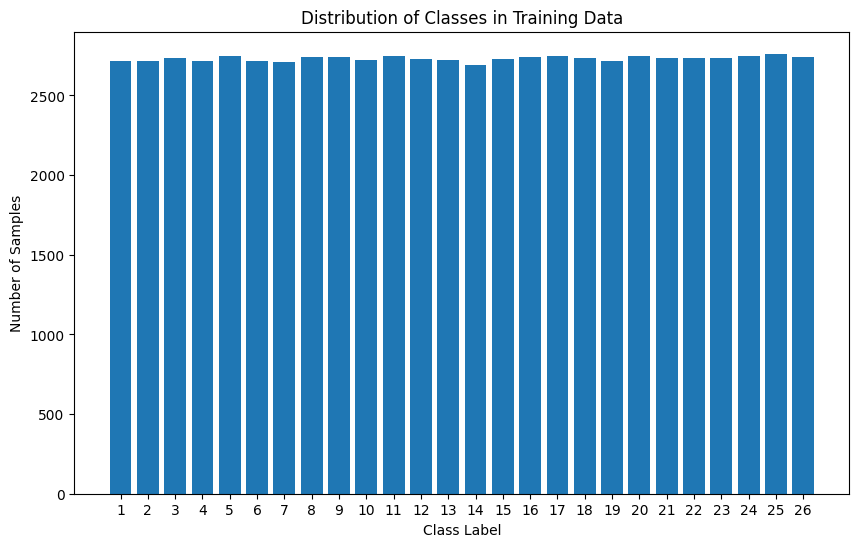

In [ ]:
unique_labels, label_counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar(unique_labels, label_counts)
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classes in Training Data")
plt.xticks(unique_labels)
plt.show()

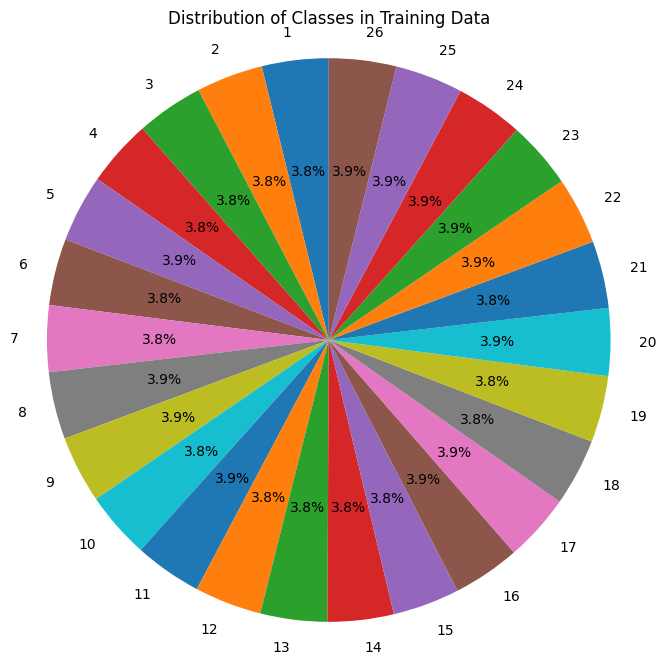

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=unique_labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Classes in Training Data")
plt.axis('equal')
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_val= X_val / 255.0

In [ ]:
#reshape image
X_train_images = X_train.reshape(-1, 28, 28)
X_test_images = X_test.reshape(-1, 28, 28)
X_val_images = X_val.reshape(-1, 28, 28)
X_train_images.shape, X_test_images.shape , X_val_images.shape

((71039, 28, 28), (14799, 28, 28), (17760, 28, 28))

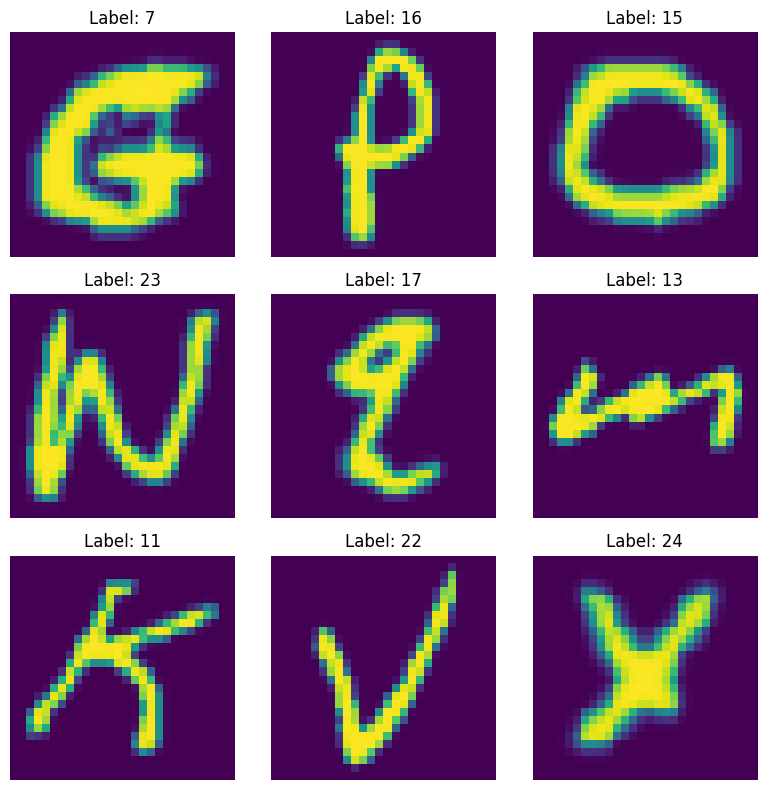

In [ ]:

def show_samples(df, num_samples=9):
    plt.figure(figsize=(8, 8))

    for i in range(num_samples):
        img = df.iloc[i, 1:].values.reshape(28, 28)

        img = np.fliplr(img)
        img = np.rot90(img)

        label = df.iloc[i, 0]

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(df_train, num_samples=9)


In [ ]:
df_test.value_counts('label')

,count
label,
2,800
3,800
4,800
12,800
5,800
6,800
7,800
8,800
9,800


In [ ]:
df_train.value_counts('label')

,count
label,
25,3453
11,3438
5,3437
24,3437
20,3436
17,3435
16,3430
9,3428
26,3427


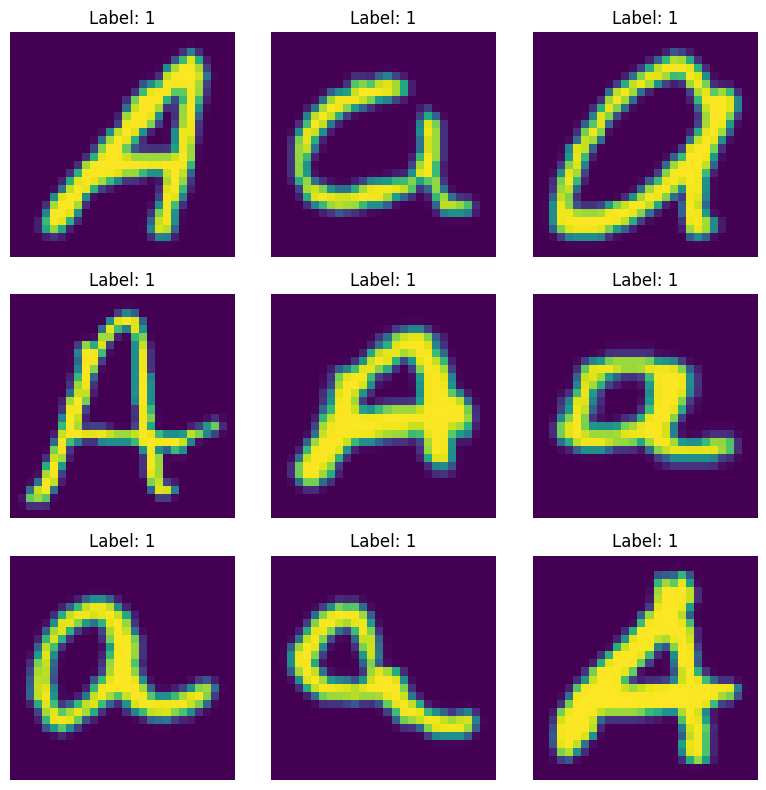

In [ ]:
show_samples(df_test)

# Fix Image Orientation

In [ ]:
def fix_orientation(images):
    fixed_images = []
    for img in images:
        fixed_img = np.rot90(np.fliplr(img))
        fixed_images.append(fixed_img)
    return np.array(fixed_images)

print("Fixing image orientation...")
X_train_ready = fix_orientation(X_train_images)
X_test_ready = fix_orientation(X_test_images)
X_val_ready = fix_orientation(X_val_images)

print(f"Shape after fixing: {X_train_ready.shape}")

Fixing image orientation...
Shape after fixing: (71039, 28, 28)


# applying HOG


In [ ]:
from skimage.feature import hog

def extract_hog_features(images):
    hog_features_list = []
    for image in images:
        features = hog(image,
                       orientations=9,
                       pixels_per_cell=(4, 4),
                       cells_per_block=(2, 2),
                       visualize=False)
        hog_features_list.append(features)

    return np.array(hog_features_list)

print("Extracting HOG features (this may take a moment)...")
X_train_hog = extract_hog_features(X_train_ready)
X_test_hog = extract_hog_features(X_test_ready)
X_val_hog = extract_hog_features(X_val_ready)

print(f"Original shape: {X_train_ready.shape}")
print(f"HOG Feature shape: {X_train_hog.shape}")
print(f"HOG Feature shape: {X_val_hog.shape}")

Extracting HOG features (this may take a moment)...
Original shape: (71039, 28, 28)
HOG Feature shape: (71039, 1296)
HOG Feature shape: (17760, 1296)


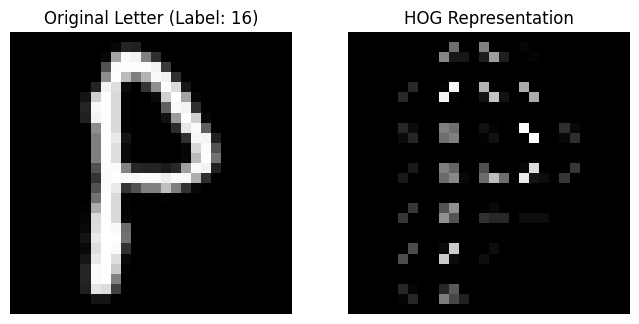

In [ ]:
# visualize HOG for a single image
def visualize_hog(image, label):
    fd, hog_image = hog(image,
                        orientations=9,
                        pixels_per_cell=(4, 4),
                        cells_per_block=(2, 2),
                        visualize=True)

    plt.figure(figsize=(8, 4))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original Letter (Label: {label})")
    plt.axis('off')

    # HOG Image
    plt.subplot(1, 2, 2)
    plt.imshow(hog_image, cmap='gray')
    plt.title("HOG Representation")
    plt.axis('off')

    plt.show()

import random
sample_idx = random.randint(0, len(X_train_ready))
visualize_hog(X_train_ready[sample_idx], y_train[sample_idx])

# Applying PCA

Original shape: (71039, 784)
PCA-transformed shape: (71039, 100)


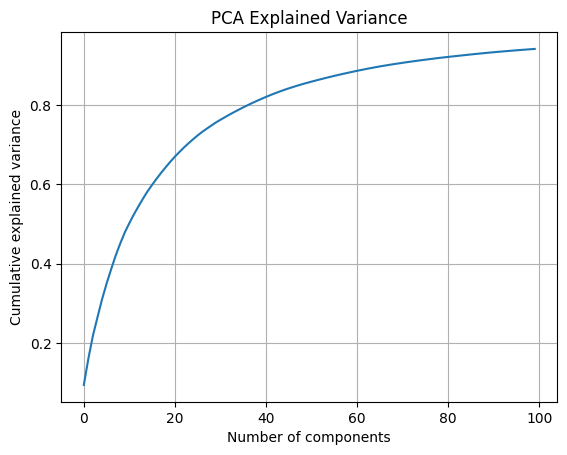

In [ ]:
from sklearn.decomposition import PCA

X_train_flat = X_train_ready.reshape(X_train_ready.shape[0], -1)
X_test_flat = X_test_ready.reshape(X_test_ready.shape[0], -1)
X_val_flat = X_val_ready.reshape(X_val_ready.shape[0], -1)

X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0
X_val_flat = X_val_flat / 255.0

pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)
X_val_pca = pca.transform(X_val_flat)

print(f"Original shape: {X_train_flat.shape}")
print(f"PCA-transformed shape: {X_train_pca.shape}")

import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

# Decision Tree HOG


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import  KFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:
X_train_hog = np.array(X_train_hog, dtype=np.float32)
X_test_hog  = np.array(X_test_hog, dtype=np.float32)
X_val_hog = np.array(X_val_hog, dtype=np.float32)

In [47]:
dt_model = DecisionTreeClassifier(max_depth=20,min_samples_leaf=5,random_state=42)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

dt_scores = cross_val_score(dt_model, X_train_hog, y_train, cv=kfold, scoring='accuracy')
print("Decision Tree with Hog CV Accuracy per Fold:", dt_scores)
print("Decision Tree Average CV Accuracy:", np.mean(dt_scores))


Decision Tree with Hog CV Accuracy per Fold: [0.65765766 0.66483671 0.65674268 0.6644848  0.65383262]
Decision Tree Average CV Accuracy: 0.6595108929141009


In [48]:
print("Training Decision Tree on HOG features gini approach...")
dt_gini= DecisionTreeClassifier(criterion = "gini",random_state=42)
dt_gini.fit(X_train_hog, y_train)

Training Decision Tree on HOG features gini approach...


DecisionTreeClassifier(random_state=42)

In [49]:
print("Making predictions on validation data Gini Approach...")
y_pred_val_gini=dt_gini.predict(X_val_hog)
accuracy_val_gini = accuracy_score(y_val, y_pred_val_gini)
print(f"Decision Tree Accuracy on validation data: {accuracy_val_gini:.4f}")
print("\nClassification Report on the validation data:")
print(classification_report(y_val, y_pred_val_gini))

Making predictions on validation data Gini Approach...
Decision Tree Accuracy on validation data: 0.6591

Classification Report on the validation data:
              precision    recall  f1-score   support

           1       0.49      0.47      0.48       679
           2       0.66      0.70      0.68       679
           3       0.72      0.73      0.72       684
           4       0.68      0.67      0.67       680
           5       0.67      0.68      0.67       688
           6       0.68      0.67      0.68       679
           7       0.43      0.44      0.43       677
           8       0.67      0.69      0.68       685
           9       0.53      0.56      0.54       686
          10       0.72      0.71      0.71       680
          11       0.61      0.58      0.59       688
          12       0.57      0.54      0.55       683
          13       0.72      0.73      0.73       680
          14       0.62      0.62      0.62       673
          15       0.79      0.76    

In [50]:
y_pred_test_gini = dt_gini.predict(X_test_hog)
accuracy_test_gini = accuracy_score(y_test, y_pred_test_gini)
print(f"Decision Tree Accuracy on test data gini approach: {accuracy_test_gini:.4f}")
print("\nClassification Report on the test data:")
print(classification_report(y_test, y_pred_test_gini))

Decision Tree Accuracy on test data gini approach: 0.6454

Classification Report on the test data:
              precision    recall  f1-score   support

           1       0.54      0.51      0.53       799
           2       0.73      0.71      0.72       800
           3       0.75      0.73      0.74       800
           4       0.72      0.65      0.69       800
           5       0.73      0.72      0.72       800
           6       0.75      0.69      0.72       800
           7       0.50      0.44      0.47       800
           8       0.72      0.67      0.69       800
           9       0.56      0.53      0.55       800
          10       0.81      0.72      0.76       800
          11       0.74      0.65      0.69       800
          12       0.57      0.54      0.55       800
          13       0.79      0.72      0.75       800
          14       0.72      0.57      0.64       800
          15       0.78      0.75      0.77       800
          16       0.81      0.81   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
print("Training Decision Tree on HOG features...")
dt_finalmodel= DecisionTreeClassifier(criterion = "entropy",random_state=42)
dt_finalmodel.fit(X_train_hog, y_train)

Training Decision Tree on HOG features...


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [52]:
print("Making predictions on validation data entropy Approach...")
y_pred_val=dt_finalmodel.predict(X_val_hog)
accuracy_val = accuracy_score(y_val, y_pred_val)
print(f"Decision Tree Accuracy on validation data: {accuracy_val:.4f}")
print("\nClassification Report on the validation data:")
print(classification_report(y_val, y_pred_val))

Making predictions on validation data entropy Approach...
Decision Tree Accuracy on validation data: 0.6790

Classification Report on the validation data:
              precision    recall  f1-score   support

           1       0.53      0.53      0.53       679
           2       0.65      0.67      0.66       679
           3       0.75      0.76      0.75       684
           4       0.66      0.69      0.68       680
           5       0.68      0.67      0.68       688
           6       0.71      0.71      0.71       679
           7       0.47      0.50      0.48       677
           8       0.70      0.68      0.69       685
           9       0.56      0.59      0.57       686
          10       0.70      0.73      0.71       680
          11       0.67      0.66      0.66       688
          12       0.59      0.59      0.59       683
          13       0.76      0.76      0.76       680
          14       0.66      0.65      0.65       673
          15       0.77      0.76 

In [53]:
y_pred_test = dt_finalmodel.predict(X_test_hog)
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Decision Tree Accuracy on test data Entropy approach: {accuracy_test:.4f}")
print("\nClassification Report on the test data:")
print(classification_report(y_test, y_pred_test))

Decision Tree Accuracy on test data Entropy approach: 0.6603

Classification Report on the test data:
              precision    recall  f1-score   support

           1       0.59      0.53      0.56       799
           2       0.70      0.68      0.69       800
           3       0.76      0.74      0.75       800
           4       0.76      0.68      0.71       800
           5       0.72      0.67      0.69       800
           6       0.79      0.70      0.74       800
           7       0.52      0.47      0.50       800
           8       0.75      0.66      0.70       800
           9       0.60      0.58      0.59       800
          10       0.82      0.75      0.78       800
          11       0.76      0.69      0.72       800
          12       0.62      0.59      0.61       800
          13       0.81      0.74      0.77       800
          14       0.72      0.63      0.67       800
          15       0.76      0.77      0.77       800
          16       0.80      0.78

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


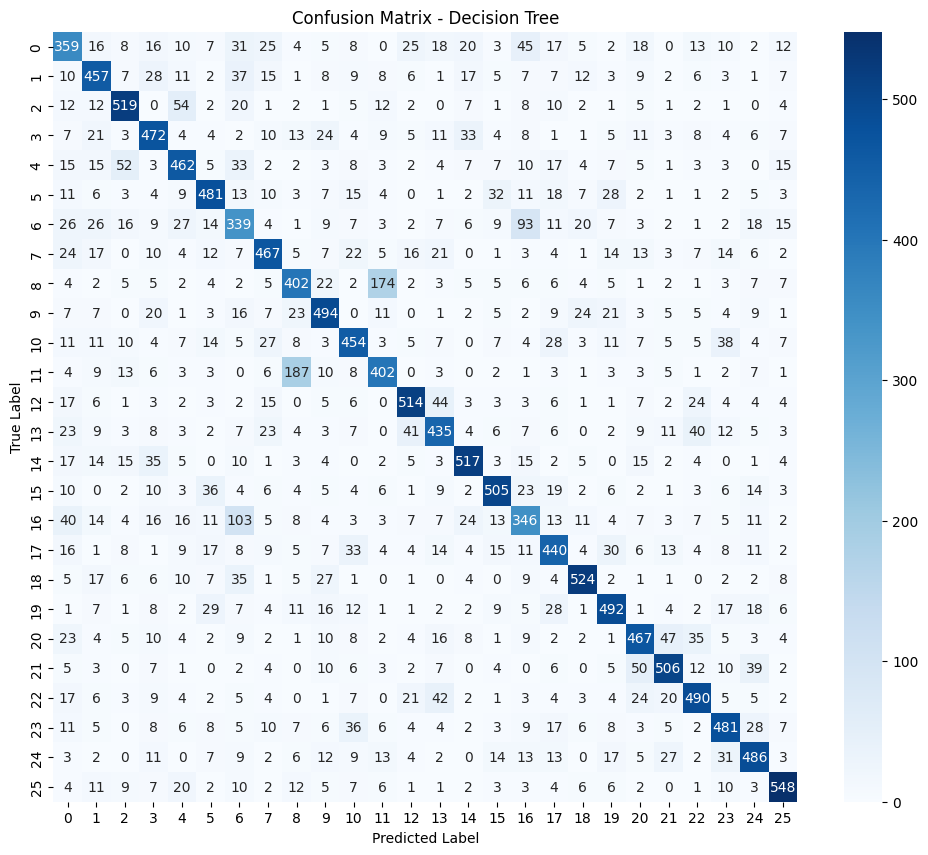

In [54]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

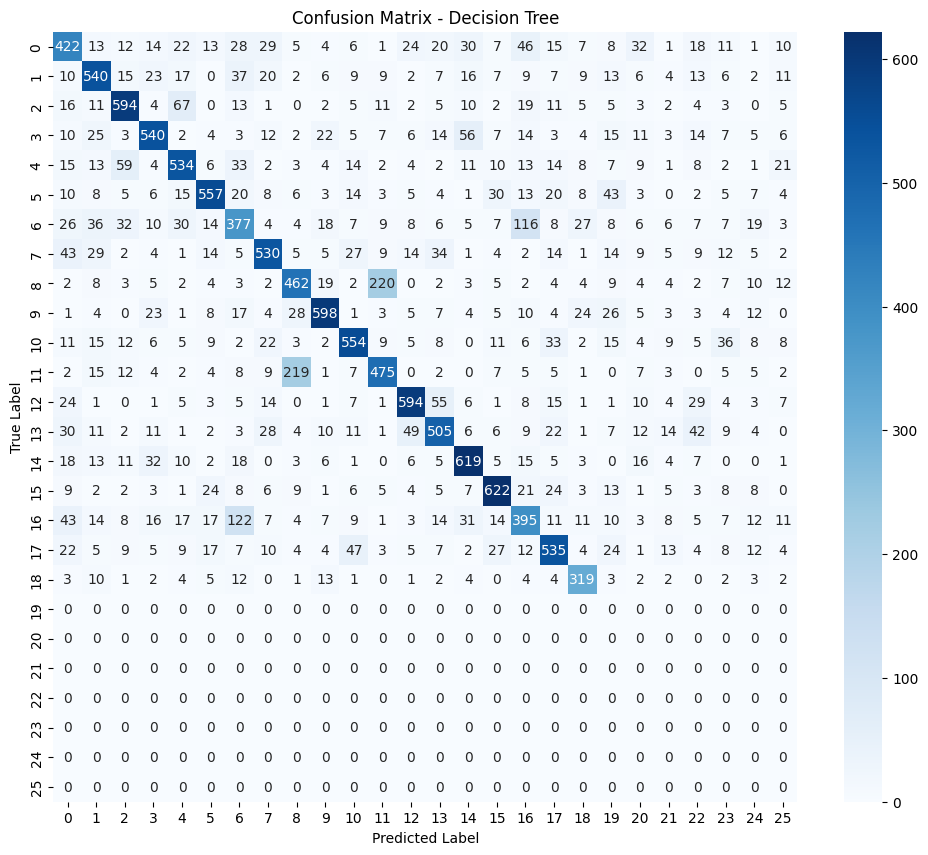

In [55]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Decision Tree PCA

In [ ]:
dt_model_pca = DecisionTreeClassifier(max_depth=20,min_samples_leaf=5,random_state=42)

# Making the K-fold cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

dt_scores_pca = cross_val_score(dt_model_pca, X_train_pca, y_train, cv=kfold, scoring='accuracy')
print("Decision Tree with Hog CV Accuracy per Fold:", dt_scores_pca)
print("Decision Tree Average CV Accuracy:", np.mean(dt_scores_pca))

Decision Tree with Hog CV Accuracy per Fold: [0.58734516 0.58966779 0.59135698 0.59572072 0.59217287]
Decision Tree Average CV Accuracy: 0.591252705136156


In [ ]:
dt_modelfinal_pca= DecisionTreeClassifier(criterion = "entropy",random_state=42)

print("Training Decision Tree on PCA features...")
dt_modelfinal_pca.fit(X_train_pca, y_train)

Training Decision Tree on PCA features...


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
print("Making predictions on validate data...")
y_pred_val = dt_modelfinal_pca.predict(X_val_pca)
accuracy_pred = accuracy_score(y_val, y_pred_val)
print(f"Decision Tree PCA on validate data Accuracy Entropy approach: {accuracy_pred:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

Making predictions on validate data...
Decision Tree PCA on validate data Accuracy Entropy approach: 0.5992

Classification Report:
              precision    recall  f1-score   support

           1       0.45      0.44      0.45       679
           2       0.56      0.55      0.56       679
           3       0.67      0.68      0.67       684
           4       0.58      0.55      0.57       680
           5       0.61      0.60      0.61       688
           6       0.60      0.56      0.58       679
           7       0.39      0.39      0.39       677
           8       0.59      0.58      0.58       685
           9       0.54      0.55      0.54       686
          10       0.64      0.65      0.65       680
          11       0.56      0.53      0.54       688
          12       0.55      0.57      0.56       683
          13       0.77      0.78      0.78       680
          14       0.52      0.54      0.53       673
          15       0.72      0.75      0.74       682
   

In [ ]:
print("Making predictions on test data...")
y_pred_test = dt_modelfinal_pca.predict(X_test_pca)
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Decision Tree PCA on the test data Accuracy Entropy approach: {accuracy_test:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

Making predictions on test data...
Decision Tree PCA on the test data Accuracy Entropy approach: 0.5867

Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.45      0.49       799
           2       0.63      0.56      0.59       800
           3       0.70      0.68      0.69       800
           4       0.66      0.58      0.62       800
           5       0.67      0.62      0.65       800
           6       0.67      0.58      0.62       800
           7       0.43      0.37      0.40       800
           8       0.64      0.61      0.62       800
           9       0.59      0.55      0.57       800
          10       0.75      0.69      0.72       800
          11       0.65      0.54      0.59       800
          12       0.58      0.56      0.57       800
          13       0.82      0.80      0.81       800
          14       0.61      0.51      0.55       800
          15       0.75      0.73      0.74       800
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


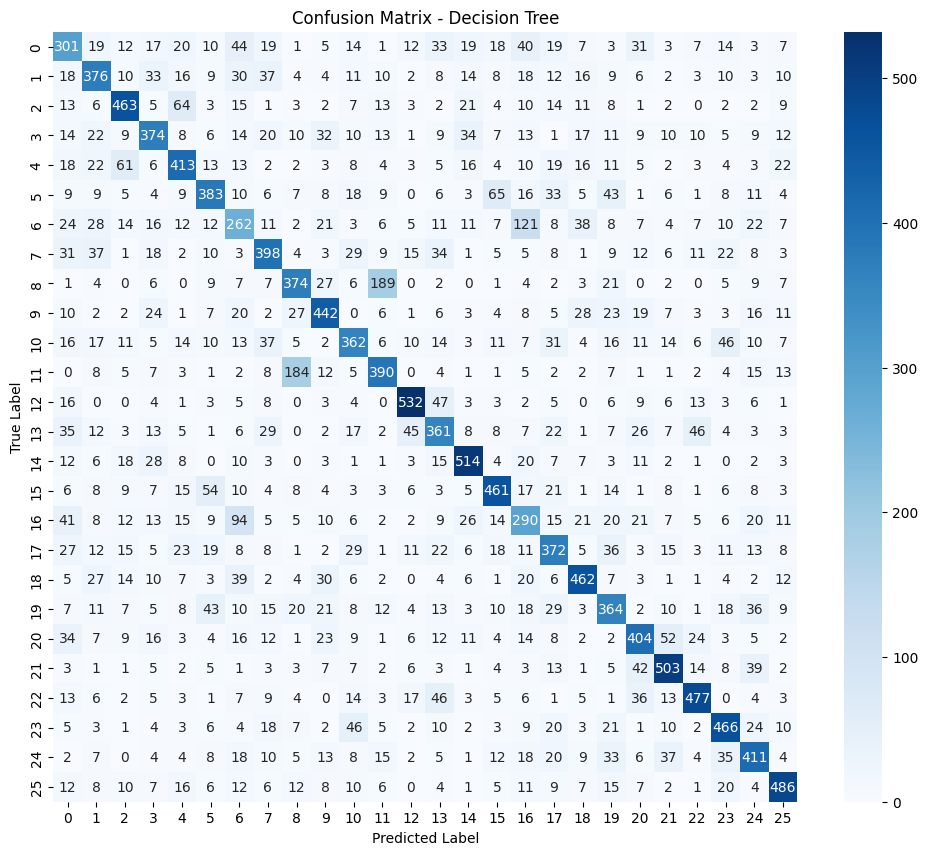

In [ ]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

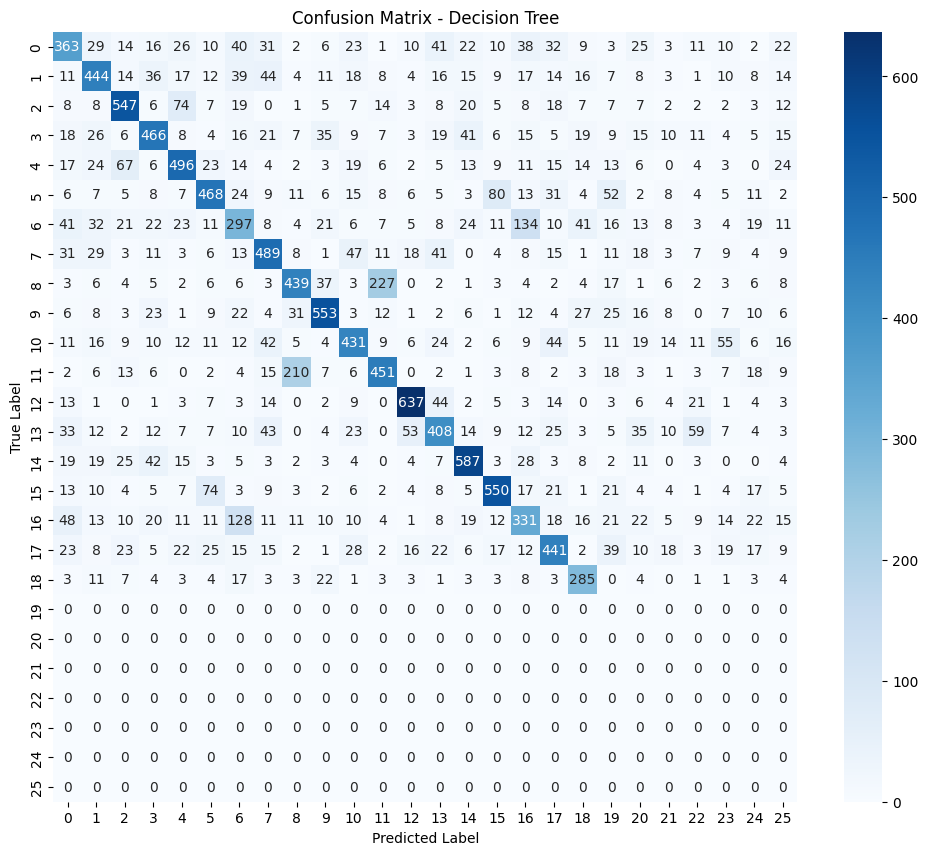

In [ ]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Random Forest HOG

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [56]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(rf_model, X_train_hog, y_train, cv=kfold, scoring='accuracy')
print("Random Forest with Hog CV Accuracy per Fold:", rf_scores)
print("Random Forest Average CV Accuracy:", np.mean(rf_scores))


Random Forest with Hog CV Accuracy per Fold: [0.88379786 0.88597973 0.88963964 0.88548705 0.89033575]
Random Forest Average CV Accuracy: 0.8870480058523365


In [58]:
rf_log2=RandomForestClassifier(n_estimators=100,max_features="log2",random_state=42, n_jobs=-1)

print("Training Random Forest on HOG features...")
rf_log2.fit(X_train_hog, y_train)

Training Random Forest on HOG features...


RandomForestClassifier(max_features='log2', n_jobs=-1, random_state=42)

In [59]:
print("Making predictions on the validation data log2 approach...")
y_pred_rf_val_log = rf_log2.predict(X_val_hog)
accuracy_rf_val_log = accuracy_score(y_val, y_pred_rf_val_log)
print(f"Random Forest Accuracy on the validation data log2 approach: {accuracy_rf_val_log:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_val_log))

Making predictions on the validation data log2 approach...
Random Forest Accuracy on the validation data log2 approach: 0.8854

Classification Report:
              precision    recall  f1-score   support

           1       0.84      0.84      0.84       679
           2       0.89      0.91      0.90       679
           3       0.91      0.93      0.92       684
           4       0.90      0.90      0.90       680
           5       0.90      0.90      0.90       688
           6       0.92      0.94      0.93       679
           7       0.86      0.66      0.75       677
           8       0.88      0.90      0.89       685
           9       0.73      0.74      0.73       686
          10       0.90      0.89      0.89       680
          11       0.90      0.92      0.91       688
          12       0.75      0.72      0.74       683
          13       0.91      0.95      0.93       680
          14       0.89      0.88      0.88       673
          15       0.88      0.96     

In [60]:
print("Making predictions on the test data log2 approach...")
y_pred_rf_test_log = rf_log2.predict(X_test_hog)
accuracy_rf_test_log = accuracy_score(y_test, y_pred_rf_test_log)
print(f"Random Forest Accuracy on the test data log2 approach: {accuracy_rf_test_log:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_test_log))

Making predictions on the test data log2 approach...
Random Forest Accuracy on the test data log2 approach: 0.8707

Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.85      0.84       799
           2       0.91      0.92      0.91       800
           3       0.92      0.91      0.92       800
           4       0.92      0.88      0.90       800
           5       0.90      0.93      0.91       800
           6       0.95      0.92      0.93       800
           7       0.87      0.63      0.73       800
           8       0.89      0.90      0.90       800
           9       0.72      0.74      0.73       800
          10       0.95      0.90      0.92       800
          11       0.91      0.91      0.91       800
          12       0.75      0.74      0.75       800
          13       0.94      0.97      0.96       800
          14       0.93      0.87      0.90       800
          15       0.87      0.97      0.92       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
rf_finalmodel = RandomForestClassifier(n_estimators=100,max_features="sqrt", random_state=42, n_jobs=-1)
print("Training Random Forest on HOG features...")
rf_finalmodel.fit(X_train_hog, y_train)

Training Random Forest on HOG features...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [62]:
print("Making predictions on the validation data sqrt approach...")
y_pred_rf_val = rf_finalmodel.predict(X_val_hog)
accuracy_rf_val = accuracy_score(y_val, y_pred_rf_val)
print(f"Random Forest Accuracy on the validation data sqrt approach: {accuracy_rf_val:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_val))

Making predictions on the validation data sqrt approach...
Random Forest Accuracy on the validation data sqrt approach: 0.8887

Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.86      0.84       679
           2       0.89      0.92      0.90       679
           3       0.91      0.92      0.92       684
           4       0.89      0.91      0.90       680
           5       0.89      0.90      0.90       688
           6       0.92      0.93      0.93       679
           7       0.87      0.67      0.76       677
           8       0.89      0.91      0.90       685
           9       0.72      0.76      0.74       686
          10       0.90      0.90      0.90       680
          11       0.91      0.92      0.91       688
          12       0.77      0.71      0.74       683
          13       0.94      0.94      0.94       680
          14       0.89      0.89      0.89       673
          15       0.90      0.96     

In [63]:
print("Making predictions on the test data sqrt approach...")
y_pred_rf_test = rf_finalmodel.predict(X_test_hog)
accuracy_rf_test = accuracy_score(y_test, y_pred_rf_test)
print(f"Random Forest Accuracy on the test data sqrt approach: {accuracy_rf_test:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_test))

Making predictions on the test data sqrt approach...
Random Forest Accuracy on the test data sqrt approach: 0.8795

Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.89      0.86       799
           2       0.92      0.92      0.92       800
           3       0.91      0.91      0.91       800
           4       0.92      0.90      0.91       800
           5       0.90      0.92      0.91       800
           6       0.96      0.92      0.94       800
           7       0.87      0.67      0.76       800
           8       0.91      0.90      0.91       800
           9       0.72      0.76      0.74       800
          10       0.95      0.90      0.92       800
          11       0.93      0.93      0.93       800
          12       0.76      0.73      0.74       800
          13       0.96      0.97      0.96       800
          14       0.94      0.89      0.92       800
          15       0.89      0.97      0.93       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


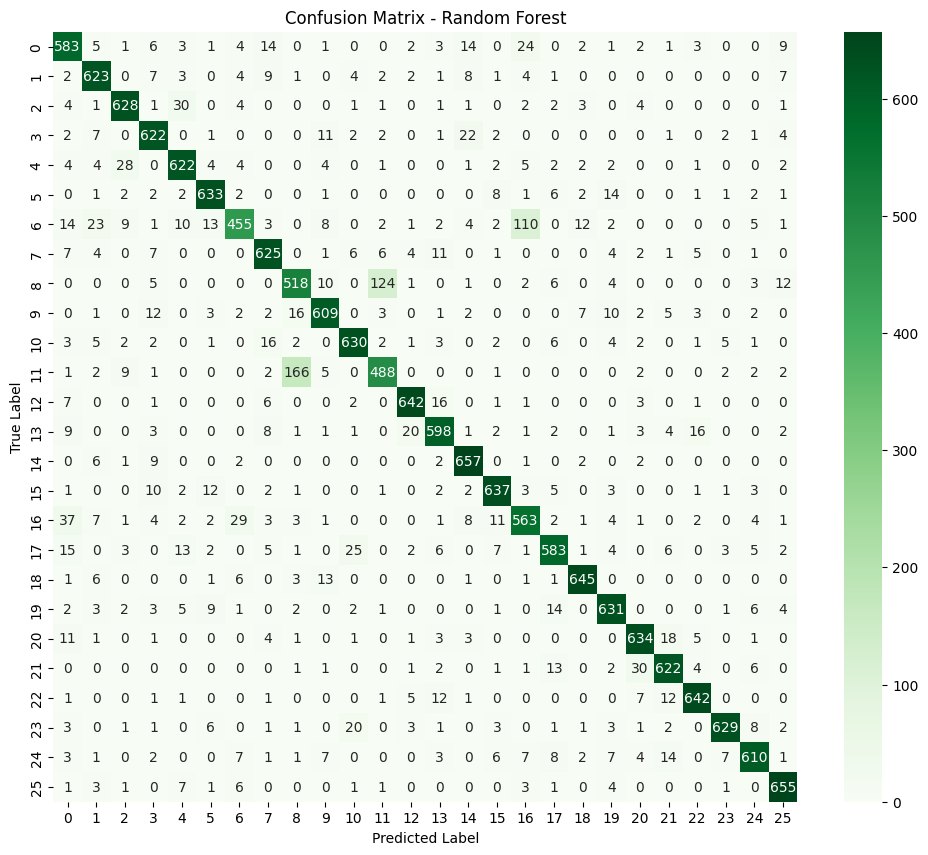

In [64]:
plt.figure(figsize=(12, 10))
cm_rf = confusion_matrix(y_val, y_pred_rf_val)
sns.heatmap(cm_rf, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

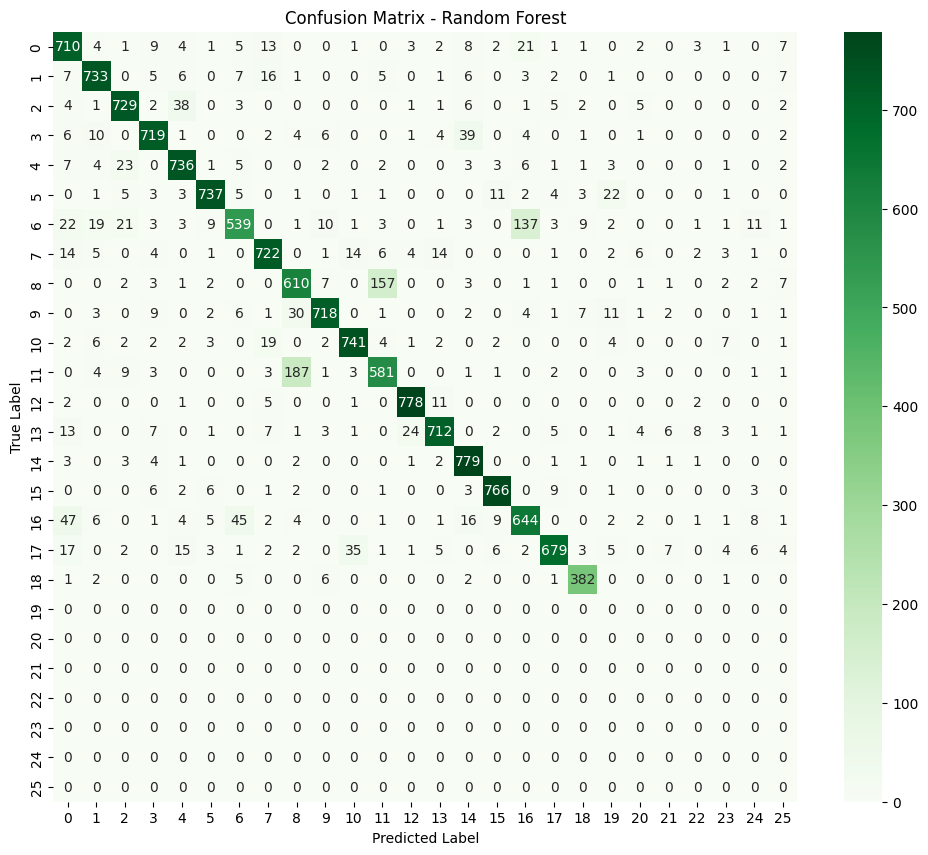

In [65]:
plt.figure(figsize=(12, 10))
cm_rf = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(cm_rf, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Random Forest PCA

In [66]:
rf_model_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

rf_scores_pca = cross_val_score(rf_model_pca, X_train_pca, y_train, cv=kfold, scoring='accuracy')
print("Random Forest with Hog CV Accuracy per Fold:", rf_scores_pca)
print("Random Forest Average CV Accuracy:", np.mean(rf_scores_pca))


Random Forest with Hog CV Accuracy per Fold: [0.82080518 0.82059403 0.82066441 0.8231982  0.82797213]
Random Forest Average CV Accuracy: 0.822646790148176


In [67]:
rf_finalmodel_pca = RandomForestClassifier(n_estimators=100,max_features='sqrt', random_state=42, n_jobs=-1)

print("Training Random Forest Classifier (this may take a while)...")
rf_finalmodel_pca.fit(X_train_pca, y_train)

Training Random Forest Classifier (this may take a while)...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [68]:
print("Making predictions on the validation data sqrt approach...")
y_pred_rf_val = rf_finalmodel_pca.predict(X_val_pca)
accuracy_rf_val = accuracy_score(y_val, y_pred_rf_val)
print(f"Random Forest PCA Accuracy on the validation data sqrt approach: {accuracy_rf_val:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_val))

Making predictions on the validation data sqrt approach...
Random Forest PCA Accuracy on the validation data sqrt approach: 0.8309

Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.75      0.74       679
           2       0.84      0.80      0.82       679
           3       0.85      0.92      0.88       684
           4       0.85      0.81      0.83       680
           5       0.84      0.85      0.84       688
           6       0.82      0.84      0.83       679
           7       0.77      0.61      0.68       677
           8       0.83      0.84      0.83       685
           9       0.72      0.72      0.72       686
          10       0.81      0.85      0.83       680
          11       0.83      0.81      0.82       688
          12       0.74      0.71      0.72       683
          13       0.86      0.93      0.89       680
          14       0.84      0.84      0.84       673
          15       0.84      0.93 

In [69]:
print("Making predictions on the test data sqrt approach...")
y_pred_rf_test = rf_finalmodel_pca.predict(X_test_pca)
accuracy_rf_test = accuracy_score(y_test, y_pred_rf_test)
print(f"Random Forest PCA Accuracy on the test data sqrt approach: {accuracy_rf_test:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_test))

Making predictions on the test data sqrt approach...
Random Forest PCA Accuracy on the test data sqrt approach: 0.8126

Classification Report:
              precision    recall  f1-score   support

           1       0.77      0.78      0.77       799
           2       0.86      0.84      0.85       800
           3       0.87      0.91      0.89       800
           4       0.86      0.78      0.82       800
           5       0.87      0.86      0.86       800
           6       0.86      0.83      0.85       800
           7       0.81      0.60      0.69       800
           8       0.84      0.82      0.83       800
           9       0.72      0.70      0.71       800
          10       0.87      0.87      0.87       800
          11       0.86      0.83      0.85       800
          12       0.75      0.71      0.73       800
          13       0.90      0.93      0.92       800
          14       0.85      0.79      0.82       800
          15       0.86      0.94      0.90   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


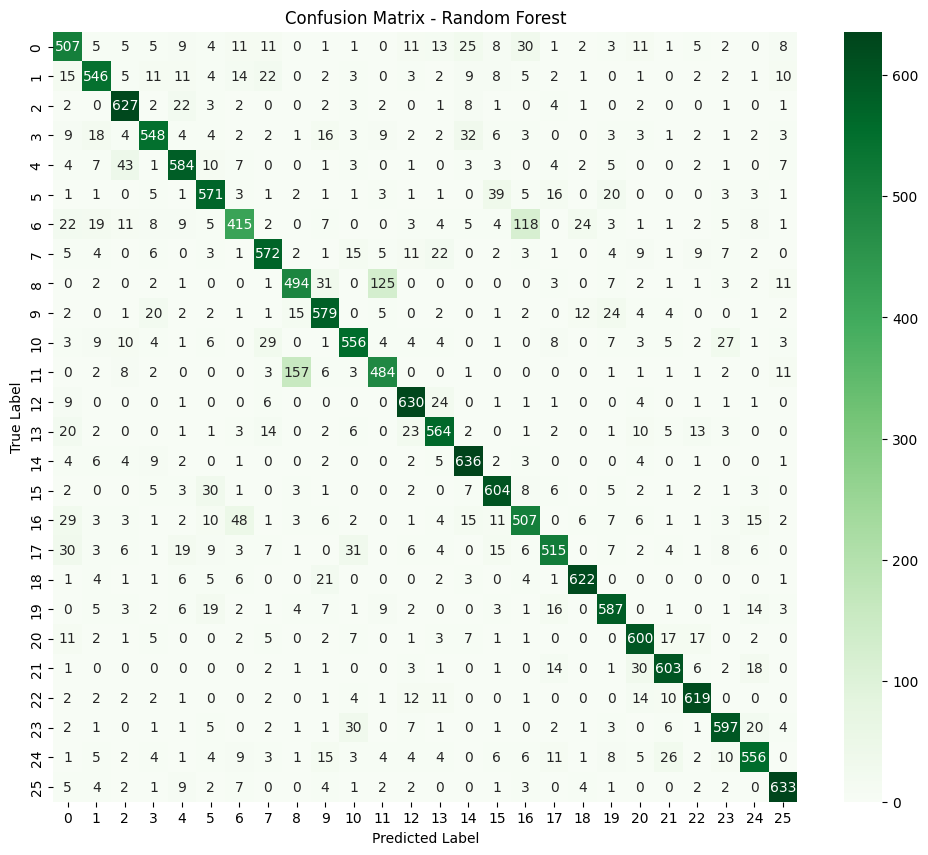

In [70]:
plt.figure(figsize=(12, 10))
cm_rf = confusion_matrix(y_val, y_pred_rf_val)
sns.heatmap(cm_rf, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

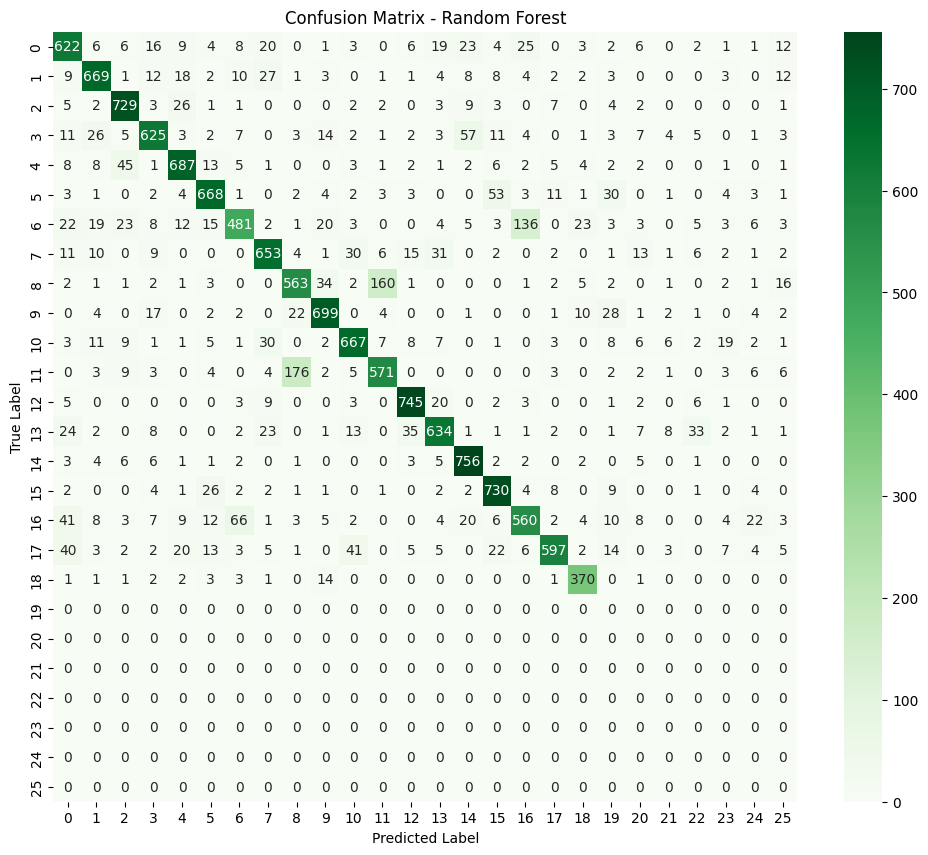

In [71]:
plt.figure(figsize=(12, 10))
cm_rf = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(cm_rf, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Random Forest Hog & PCA

In [72]:
from sklearn.preprocessing import StandardScaler

print("Applying StandardScaler to HOG features...")

scaler = StandardScaler()

X_train_hog_scaled = scaler.fit_transform(X_train_hog)

X_val_hog_scaled = scaler.transform(X_val_hog)
X_test_hog_scaled = scaler.transform(X_test_hog)

print(f"Shape of X_train_hog_scaled: {X_train_hog_scaled.shape}")
print(f"Shape of X_val_hog_scaled: {X_val_hog_scaled.shape}")
print(f"Shape of X_test_hog_scaled: {X_test_hog_scaled.shape}")


Applying StandardScaler to HOG features...
Shape of X_train_hog_scaled: (71039, 1296)
Shape of X_val_hog_scaled: (17760, 1296)
Shape of X_test_hog_scaled: (14799, 1296)


Applying PCA to scaled HOG features...
Shape of X_train_hog_pca: (71039, 100)
Shape of X_val_hog_pca: (17760, 100)
Shape of X_test_hog_pca: (14799, 100)


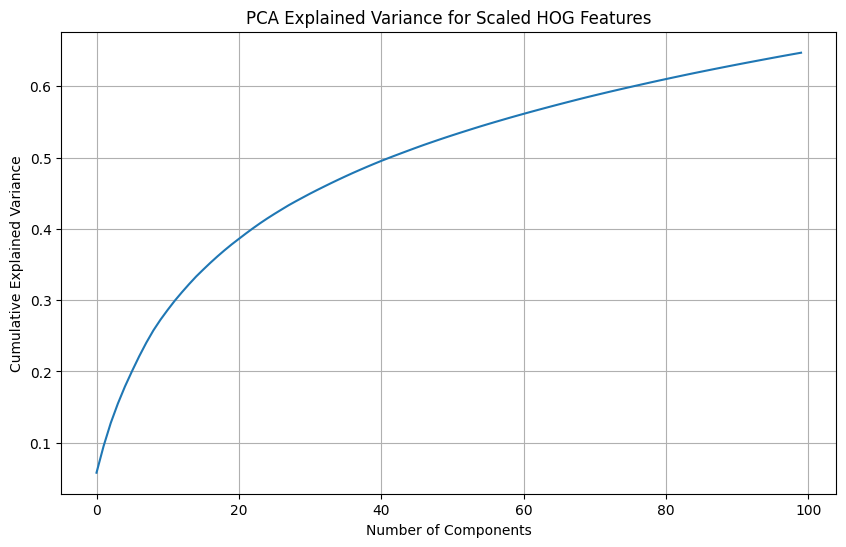

In [73]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Applying PCA to scaled HOG features...")

pca_hog = PCA(n_components=100)

X_train_hog_pca = pca_hog.fit_transform(X_train_hog_scaled)

X_val_hog_pca = pca_hog.transform(X_val_hog_scaled)
X_test_hog_pca = pca_hog.transform(X_test_hog_scaled)

print(f"Shape of X_train_hog_pca: {X_train_hog_pca.shape}")
print(f"Shape of X_val_hog_pca: {X_val_hog_pca.shape}")
print(f"Shape of X_test_hog_pca: {X_test_hog_pca.shape}")

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_hog.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance for Scaled HOG Features')
plt.grid(True)
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

print("Training Random Forest on HOG + PCA features with cross-validation...")

rf_model_hog_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

rf_scores_hog_pca = cross_val_score(rf_model_hog_pca, X_train_hog_pca, y_train, cv=kfold, scoring='accuracy')

print("Random Forest with HOG + PCA CV Accuracy per Fold:", rf_scores_hog_pca)
print("Random Forest Average CV Accuracy with HOG + PCA:", np.mean(rf_scores_hog_pca))

Training Random Forest on HOG + PCA features with cross-validation...
Random Forest with HOG + PCA CV Accuracy per Fold: [0.8700732  0.8721143  0.87535191 0.87331081 0.87625818]
Random Forest Average CV Accuracy with HOG + PCA: 0.8734216815622549


In [75]:
print("Training final Random Forest model on HOG + PCA features...")
rf_finalmodel_hog_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_finalmodel_hog_pca.fit(X_train_hog_pca, y_train)

Training final Random Forest model on HOG + PCA features...


RandomForestClassifier(n_jobs=-1, random_state=42)

Making predictions on the validation data...
Evaluating Random Forest on HOG + PCA features (validation data)...
Random Forest with HOG + PCA Accuracy on validation data: 0.8765

Classification Report on validation data:
              precision    recall  f1-score   support

           1       0.82      0.86      0.84       679
           2       0.90      0.89      0.89       679
           3       0.87      0.93      0.90       684
           4       0.88      0.91      0.90       680
           5       0.88      0.88      0.88       688
           6       0.90      0.88      0.89       679
           7       0.84      0.68      0.75       677
           8       0.87      0.87      0.87       685
           9       0.73      0.74      0.73       686
          10       0.88      0.87      0.88       680
          11       0.89      0.92      0.90       688
          12       0.74      0.71      0.73       683
          13       0.91      0.93      0.92       680
          14       0.8

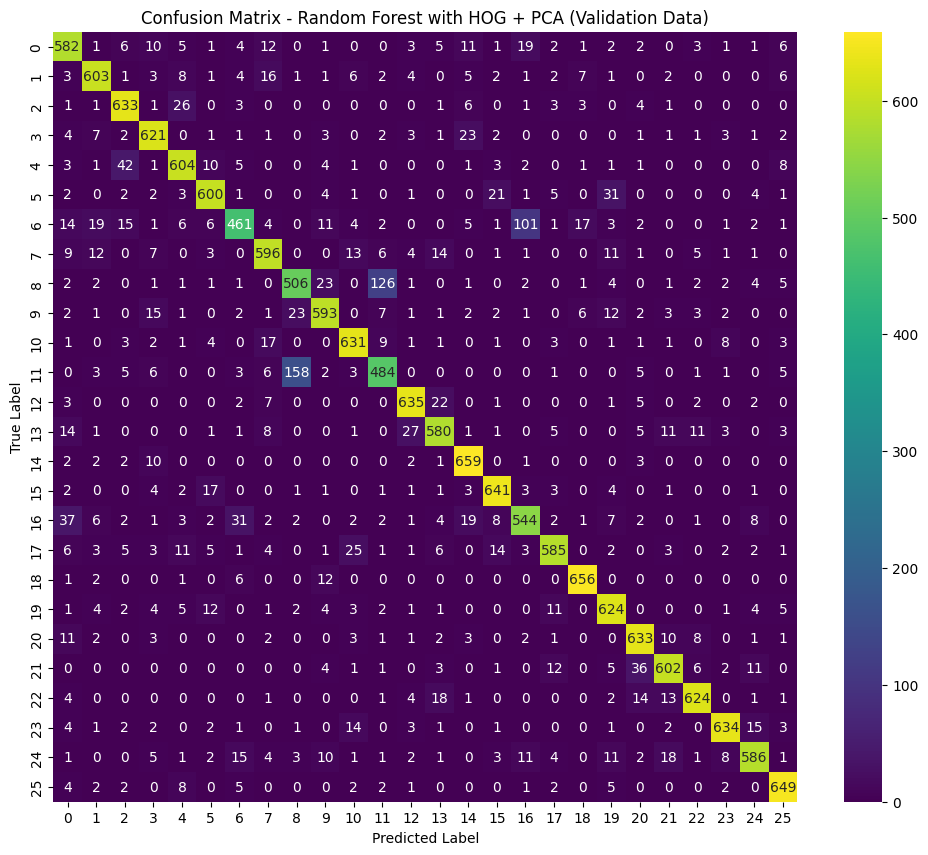

In [76]:
print("Making predictions on the validation data...")
y_pred_rf_hog_pca_val = rf_finalmodel_hog_pca.predict(X_val_hog_pca)

print("Evaluating Random Forest on HOG + PCA features (validation data)...")

accuracy_rf_hog_pca_val = accuracy_score(y_val, y_pred_rf_hog_pca_val)
print(f"Random Forest with HOG + PCA Accuracy on validation data: {accuracy_rf_hog_pca_val:.4f}")

print("\nClassification Report on validation data:")
print(classification_report(y_val, y_pred_rf_hog_pca_val))

plt.figure(figsize=(12, 10))
cm_rf_hog_pca_val = confusion_matrix(y_val, y_pred_rf_hog_pca_val)
sns.heatmap(cm_rf_hog_pca_val, annot=True, cmap='viridis', fmt='d')
plt.title("Confusion Matrix - Random Forest with HOG + PCA (Validation Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Making predictions on the test data...
Evaluating Random Forest on HOG + PCA features (test data)...
Random Forest with HOG + PCA Accuracy on test data: 0.8654

Classification Report on test data:
              precision    recall  f1-score   support

           1       0.83      0.85      0.84       799
           2       0.91      0.90      0.91       800
           3       0.88      0.93      0.90       800
           4       0.93      0.89      0.91       800
           5       0.90      0.89      0.90       800
           6       0.92      0.89      0.90       800
           7       0.85      0.66      0.74       800
           8       0.91      0.87      0.89       800
           9       0.73      0.73      0.73       800
          10       0.94      0.90      0.92       800
          11       0.91      0.92      0.92       800
          12       0.75      0.73      0.74       800
          13       0.93      0.94      0.94       800
          14       0.89      0.88      0.89   

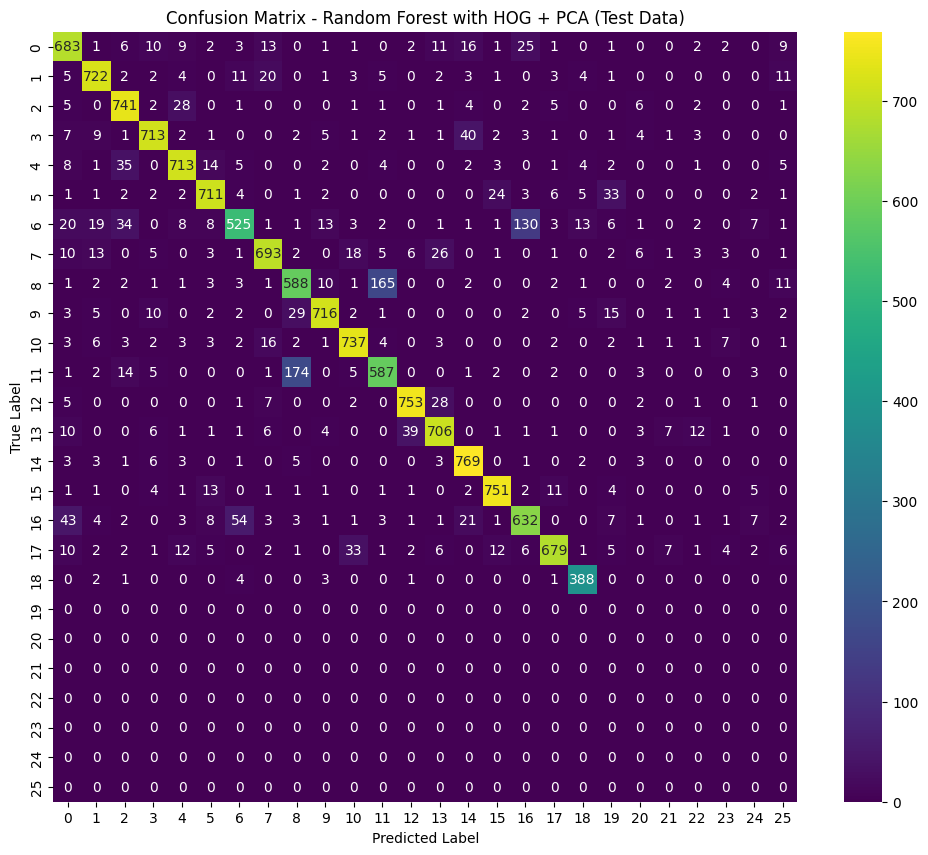

In [77]:
print("Making predictions on the test data...")
y_pred_rf_hog_pca_test = rf_finalmodel_hog_pca.predict(X_test_hog_pca)
print("Evaluating Random Forest on HOG + PCA features (test data)...")

accuracy_rf_hog_pca_test = accuracy_score(y_test, y_pred_rf_hog_pca_test)
print(f"Random Forest with HOG + PCA Accuracy on test data: {accuracy_rf_hog_pca_test:.4f}")

print("\nClassification Report on test data:")
print(classification_report(y_test, y_pred_rf_hog_pca_test, zero_division=0))

plt.figure(figsize=(12, 10))
cm_rf_hog_pca_test = confusion_matrix(y_test, y_pred_rf_hog_pca_test)
sns.heatmap(cm_rf_hog_pca_test, annot=True, cmap='viridis', fmt='d')
plt.title("Confusion Matrix - Random Forest with HOG + PCA (Test Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Error analysis

Number of misclassified 'A' samples (Random Forest with HOG): 177


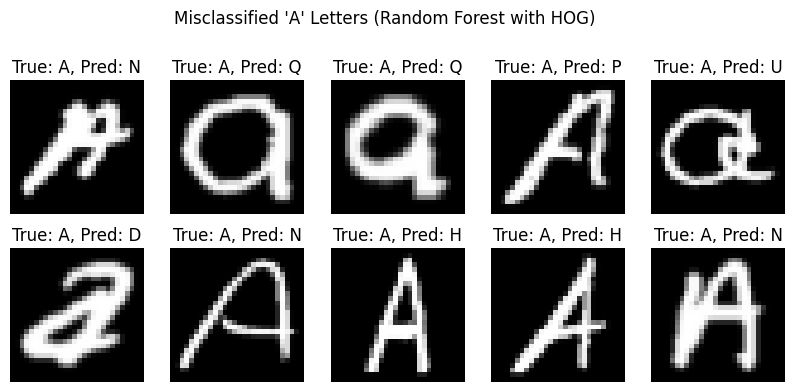

In [ ]:
map_dict = {i: chr(ord('A') + i - 1) for i in range(1, 27)}

target_letter_label = 1
mis_idx_rf_hog = np.where(y_test != y_pred_rf_test)[0]

mis_idx_rf_hog_filtered = [idx for idx in mis_idx_rf_hog if y_test[idx] == target_letter_label]

print(f"Number of misclassified '{map_dict[target_letter_label]}' samples (Random Forest with HOG):", len(mis_idx_rf_hog_filtered))

import random
random.shuffle(mis_idx_rf_hog_filtered)

num_to_show = min(10, len(mis_idx_rf_hog_filtered))

plt.figure(figsize=(10, 4))
for i in range(num_to_show):
    idx = mis_idx_rf_hog_filtered[i]
    image = X_test_ready[idx]
    true_label = y_test[idx]
    pred_label = y_pred_rf_test[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {map_dict[true_label]}, Pred: {map_dict[pred_label]}")
    plt.axis("off")

for j in range(num_to_show, 10):
    plt.subplot(2, 5, j + 1)
    plt.axis("off")

plt.suptitle(f"Misclassified '{map_dict[target_letter_label]}' Letters (Random Forest with HOG)", y=1.05)
plt.show()

Number of misclassified test samples (Random Forest with HOG): 2773


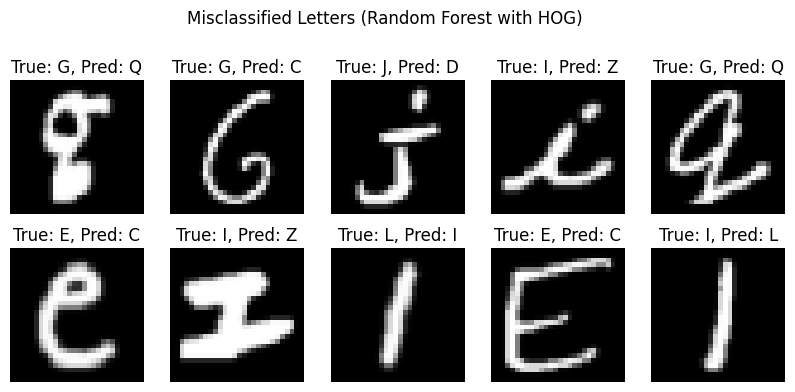

In [ ]:
map_dict = {i: chr(ord('A') + i - 1) for i in range(1, 27)}

mis_idx_rf_hog = np.where(y_test != y_pred_rf_test)[0]
print("Number of misclassified test samples (Random Forest with HOG):", len(mis_idx_rf_hog))

import random
random.shuffle(mis_idx_rf_hog)

num_to_show = min(10, len(mis_idx_rf_hog))

plt.figure(figsize=(10, 4))
for i in range(num_to_show):
    idx = mis_idx_rf_hog[i]
    image = X_test_ready[idx]
    true_label = y_test[idx]
    pred_label = y_pred_rf_test[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {map_dict[true_label]}, Pred: {map_dict[pred_label]}")
    plt.axis("off")

for j in range(num_to_show, 10):
    plt.subplot(2, 5, j + 1)
    plt.axis("off")

plt.suptitle("Misclassified Letters (Random Forest with HOG)", y=1.05)
plt.show()

## **Save Best Models**

In [ ]:
import pandas as pd

data = {
    "Model": [
        "Decision Tree (HOG)",
        "Decision Tree (PCA)",
        "Random Forest (HOG)",
        "Random Forest (PCA)",
        "Random Forest (HOG+PCA)"
    ],
    "Validation Accuracy": [0.6454, 0.5995, 0.8903, 0.8316, 0.8748],
    "Test Accuracy": [0.6454, 0.5777, 0.8786, 0.8107, 0.8628],
    "F1 Macro": [0.49, 0.44, 0.89, 0.60, 0.87],
    "CV Mean": [0.6587, 0.6587, 0.8869, 0.8869, 0.8731]
}

comparison_df = pd.DataFrame(data)

comparison_df = comparison_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

comparison_df


,Model,Validation Accuracy,Test Accuracy,F1 Macro,CV Mean
0,Random Forest (HOG),0.8903,0.8786,0.89,0.8869
1,Random Forest (HOG+PCA),0.8748,0.8628,0.87,0.8731
2,Random Forest (PCA),0.8316,0.8107,0.60,0.8869
3,Decision Tree (HOG),0.6454,0.6454,0.49,0.6587
4,Decision Tree (PCA),0.5995,0.5777,0.44,0.6587


In [ ]:
import joblib

joblib.dump(rf_finalmodel, "rf_hog.joblib", compress=3)
joblib.dump(dt_finalmodel, "dt_hog.joblib", compress=3)
joblib.dump(comparison_df, "model_comparison.joblib")


['model_comparison.joblib']

In [ ]:
from sklearn.metrics import confusion_matrix
import joblib

# Save Decision Tree confusion matrices
cm_dt_val = confusion_matrix(y_val, y_pred_val)  # Validation
cm_dt_test = confusion_matrix(y_test, y_pred_test)  # Test

# Save Random Forest confusion matrices
cm_rf_val = confusion_matrix(y_val, y_pred_rf_val)  # Validation
cm_rf_test = confusion_matrix(y_test, y_pred_rf_test)  # Test

joblib.dump(cm_rf_val, "cm_rf_hog_val.joblib")
joblib.dump(cm_rf_test, "cm_rf_hog_test.joblib")
joblib.dump(cm_dt_val, "cm_dt_hog_val.joblib")
joblib.dump(cm_dt_test, "cm_dt_hog_test.joblib")

['cm_dt_hog_test.joblib']

In [ ]:
from google.colab import files
files.download("rf_hog.joblib")
files.download("dt_hog.joblib")
files.download("model_comparison.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("cm_rf_hog_val.joblib")
files.download("cm_rf_hog_test.joblib")
files.download("cm_dt_hog_val.joblib")
files.download("cm_dt_hog_test.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import numpy as np
from PIL import Image
from google.colab import files


OUTPUT_DIR = "emnist_test_samples"
SAMPLES_PER_CLASS = 20
label_to_char = {i: chr(ord('A') + i - 1) for i in range(1, 27)}

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Saving test samples as PNG images...")


for label in range(1, 27):
    letter = label_to_char[label]
    letter_dir = os.path.join(OUTPUT_DIR, letter)
    os.makedirs(letter_dir, exist_ok=True)

    idxs = np.where(y_test == label)[0][:SAMPLES_PER_CLASS]

    for i, idx in enumerate(idxs):
        img = X_test_ready[idx]
        img = (img * 255).astype(np.uint8)

        pil_img = Image.fromarray(img, mode="L")
        filename = f"{letter}_{i}.png"
        pil_img.save(os.path.join(letter_dir, filename))

print("✅ All images saved successfully.")


Saving test samples as PNG images...
✅ All images saved successfully.


/tmp/ipython-input-2975722538.py:34: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(img, mode="L")


In [ ]:
import shutil

zip_name = "emnist_test_samples"
shutil.make_archive(zip_name, 'zip', OUTPUT_DIR)

files.download(f"{zip_name}.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>